<a href="https://colab.research.google.com/github/jpandersen61/MySQLNotebooks/blob/main/Extracting_HotelDB_To_Excel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SQL-udtræk fra hotel database til Excel

Databasens struktur er vist i nedenstående ER-Diagram

###ER-Diagram

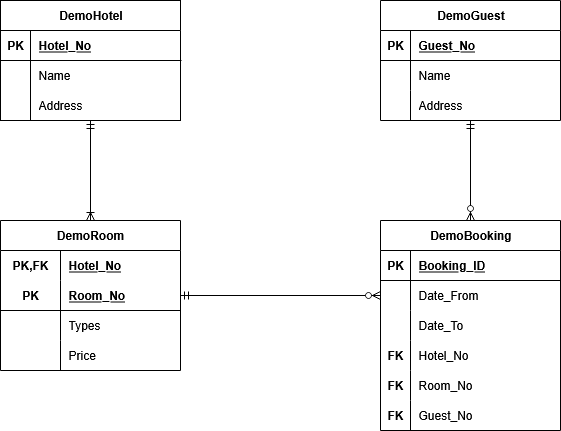

###Installér nødvendige komponenter og indfør diverse opsætninger

In [1]:
pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 31.2 MB/s eta 0:00:00


In [2]:
import mysql.connector
import pandas as pd


In [3]:
import warnings
warnings.filterwarnings('ignore')

###Connect til MySQL hotel database

In [4]:
mydb = mysql.connector.connect(
  host="mysql15.unoeuro.com",
  user="jean_zealand_dk",
  password="n25hwtBx9mcEdbar3RGy",
  database="jean_zealand_dk_db_HotelDB"
)

###Opgave: Del A - SELECT fra én tabel

1. List alle oplysninger om alle hoteller.

In [5]:
query = "SELECT * FROM DemoHotel;"
query_result = pd.read_sql(query,mydb)
query_result

,Hotel_No,Name,Address
0,1,The Pope,Vaticanstreet 1 1111 Bishopcity
1,2,Lucky Star,Lucky Road 12 2222 Hometown
2,3,Discount,Inexpensive Road 7 3333 Cheaptown
3,4,deLuxeCapital,Luxury Road 99 4444 Luxus
4,5,Discount,Inexpensive Street 12 6666 Pricetown
5,6,Prindsen,"Algade 5, 4000 Roskilde"
6,7,Scandic,"Sdr. Ringvej 5, 4000 Roskilde"


2. List alle oplysninger om alle hoteller i Roskilde.
Hint: Anvend SQL LIKE operatoren i din WHERE clause

In [6]:
query = "SELECT * FROM DemoHotel WHERE Address LIKE '%4000 Roskilde';"
query_result = pd.read_sql(query,mydb)
query_result

,Hotel_No,Name,Address
0,6,Prindsen,"Algade 5, 4000 Roskilde"
1,7,Scandic,"Sdr. Ringvej 5, 4000 Roskilde"


3. List navne og adresser på alle gæster fra Roskilde. Hint: Anvend SQL LIKE operatoren i din WHERE clause

In [7]:
query = "SELECT * FROM DemoGuest WHERE Address LIKE '%4000 Roskilde';"
query_result = pd.read_sql(query,mydb)
query_result

,Guest_No,Name,Address
0,9,Godzilla,"Dommervænget 16A, 4000 Roskilde"
1,10,KingKong,"Hyrdevænget 38, 4000 Roskilde"
2,11,KongHans,"Algade 10, 4000 Roskilde"
3,12,Hans,"Vikingevej 45, 4000 Roskilde"
4,13,Poul,"Domkirkevej 12, 4000 Roskilde"
5,14,Erik,"Hestetorvet 8, 4000 Roskilde"
6,15,Ulla,"Stændertorvet 4, 4000 Roskilde"
7,16,Yrsa,"Sdr. Ringvej 21, 4000 Roskilde"
8,17,Yvonne,"Østre Ringvej 12, 4000 Roskilde"
9,18,Tim,"Ringstedgade 33, 4000 Roskilde"


4. List navne og adresser på alle gæster fra Roskilde sorteret alfabetisk efter navn.

In [8]:
query = "SELECT * FROM DemoGuest WHERE Address LIKE '%4000 Roskilde' ORDER BY name;"
query_result = pd.read_sql(query,mydb)
query_result

,Guest_No,Name,Address
0,30,Arn,"Vindingevej 23, 4000 Roskilde"
1,29,Dana,"Byageren 12, 4000 Roskilde"
2,14,Erik,"Hestetorvet 8, 4000 Roskilde"
3,20,Erland,"Skovbovængets alle 3, 4000 Roskilde"
4,21,Erwin,"Ternevej 17, 4000 Roskilde"
5,24,Frede,"Københavnsvej 25, 4000 Roskilde"
6,9,Godzilla,"Dommervænget 16A, 4000 Roskilde"
7,12,Hans,"Vikingevej 45, 4000 Roskilde"
8,28,John,"By03ken 56, 4000 Roskilde"
9,26,Jørn,"Dronning Amaliesvej 22, 4000 Roskilde"


5. List alle dobbeltværelser med en pris under 200 pr. nat.

In [9]:
query = "SELECT * FROM DemoRoom WHERE Types='D' AND Price<200;"
query_result = pd.read_sql(query,mydb)
query_result

,Room_No,Hotel_No,Types,Price
0,1,3,D,175.0
1,2,3,D,180.0
2,2,5,D,170.0


6. List alle dobbeltværelser eller familierum med en pris under 400 pr. nat.

In [10]:
query = "SELECT * FROM DemoRoom WHERE (Price < 400) AND (Types IN ('D','F'))"
query_result = pd.read_sql(query,mydb)
query_result

,Room_No,Hotel_No,Types,Price
0,1,2,D,230.0
1,1,3,D,175.0
2,1,5,D,250.0
3,1,6,D,290.0
4,1,7,D,200.0
5,2,1,D,200.0
6,2,2,D,230.0
7,2,3,D,180.0
8,2,5,D,170.0
9,2,7,D,200.0


7. List alle dobbeltværelser eller familierum med en pris under 400 pr. nat sorteret i stigende orden efter pris.

In [11]:
query = "SELECT * FROM DemoRoom WHERE (Price < 400) AND (Types IN ('D','F')) ORDER BY Price"
query_result = pd.read_sql(query,mydb)
query_result

,Room_No,Hotel_No,Types,Price
0,2,5,D,170.0
1,1,3,D,175.0
2,2,3,D,180.0
3,3,1,D,200.0
4,4,7,D,200.0
5,4,1,D,200.0
6,3,7,D,200.0
7,2,7,D,200.0
8,2,1,D,200.0
9,1,7,D,200.0


8. List alle gæster, som har et navn, der starter med 'G'.

In [12]:
query = "SELECT * FROM DemoGuest WHERE Name LIKE 'G%'"
query_result = pd.read_sql(query,mydb)
query_result

,Guest_No,Name,Address
0,3,Goeg,"Sunset Blvd. 8, 2222 Hjemby"
1,4,Gokke,"Sunset Blvd. 8, 2222 Hjemby"
2,9,Godzilla,"Dommervænget 16A, 4000 Roskilde"


### Opgave: Del B -  Aggregate-funktioner

1. Hvor mange hoteller er der?

In [13]:
query = "SELECT COUNT(hotel_no) FROM DemoRoom"
query_result = pd.read_sql(query,mydb)
query_result


,COUNT(hotel_no)
0,53


2. Hvor mange hoteller er der i Roskilde?

In [14]:
query = "SELECT COUNT(hotel_no) FROM DemoHotel WHERE Address LIKE '%4000 Roskilde'"
query_result = pd.read_sql(query,mydb)
query_result

,COUNT(hotel_no)
0,2


3. Hvad er gennemsnitsprisen på et værelse?

In [15]:
query = "SELECT AVG(price) FROM DemoRoom"
query_result = pd.read_sql(query,mydb)
query_result

,AVG(price)
0,244.339623


4. Hvad er gennemsnitsprisen på et enkeltværelse?

In [16]:
query = "SELECT AVG(price) FROM DemoRoom WHERE Types = 'S'"
query_result = pd.read_sql(query,mydb)
query_result

,AVG(price)
0,177.0


5. Hvad er gennemsnitsprisen på et dobbeltværelse?

In [17]:
query = "SELECT AVG(price) FROM DemoRoom WHERE Types = 'S'"
query_result = pd.read_sql(query,mydb)
query_result

,AVG(price)
0,177.0


6. Hvad er gennemsnitsprisen på et værelse på Hotel ScANDic?

In [18]:
query = "SELECT AVG(price) FROM DemoRoom WHERE (hotel_no = 7)"
query_result = pd.read_sql(query,mydb)
query_result

,AVG(price)
0,190.0


7. Hvad er den totale omsætning pr. nat for alle dobbeltværelser?

In [19]:
query = "SELECT SUM(price) FROM DemoRoom WHERE Types = 'D'"
query_result = pd.read_sql(query,mydb)
query_result


,SUM(price)
0,4985.0


8. Hvor mange forskellige gæster har foretaget bookinger i marts måned? Hint: Anvend "Select by sub-selecting"

In [20]:
query = "SELECT COUNT(t.GuestNo) FROM (SELECT distinct Guest_No AS GuestNo FROM DemoBooking WHERE (Date_FROM BETWEEN '2011-03-01' AND '2011-03-31') OR (Date_to BETWEEN '2011-03-01' AND '2011-03-31')) t"
query_result = pd.read_sql(query,mydb)
query_result

,COUNT(t.GuestNo)
0,5


###Opgave: Del C -  Flere tabeller

1. List pris og type på alle værelser på 'Prindsen'. Hint: Anvend en SQL LEFT JOIN operation

In [21]:
query = "SELECT Name, Room_No, Price,Types FROM DemoHotel LEFT JOIN DemoRoom ON DemoHotel.Hotel_No = DemoRoom.Hotel_No WHERE DemoHotel.Hotel_no = 6"
query_result = pd.read_sql(query,mydb)
query_result

,Name,Room_No,Price,Types
0,Prindsen,1,290.0,D
1,Prindsen,11,185.0,S
2,Prindsen,21,360.0,F
3,Prindsen,22,370.0,F
4,Prindsen,23,380.0,F
5,Prindsen,24,380.0,F


2. List antal værelser for hvert hotel.

In [22]:
query = "SELECT DemoHotel.Name, Count(DemoRoom.Room_No ) AS 'NumOfRooms' FROM DemoHotel LEFT JOIN DemoRoom ON DemoHotel.Hotel_No = DemoRoom.Hotel_No GROUP BY DemoHotel.Name"
query_result = pd.read_sql(query,mydb)
query_result


,Name,NumOfRooms
0,The Pope,9
1,Lucky Star,8
2,Discount,13
3,deLuxeCapital,5
4,Prindsen,6
5,Scandic,12


In [23]:
query = """
SELECT * FROM DemoBooking
"""
query_result = pd.read_sql(query,mydb)
query_result

,Booking_id,Hotel_No,Guest_No,Date_From,Date_To,Room_No
0,1,1,4,2011-02-02,2011-02-06,11
1,2,1,3,2011-04-04,2011-04-06,22
2,3,2,3,2011-03-18,2011-03-22,11
3,4,3,1,2011-05-22,2011-05-28,31
4,5,3,10,2011-02-04,2011-02-12,21
5,6,4,2,2011-02-02,2011-02-06,3
6,7,4,2,2011-04-20,2011-04-24,3
7,8,4,7,2011-04-19,2011-04-24,2
8,9,4,8,2011-02-28,2011-03-05,12
9,10,4,6,2011-04-11,2011-04-12,11


### Export til Excel

In [38]:
query = """
SELECT *
FROM DemoHotel
LEFT JOIN DemoRoom ON DemoHotel.Hotel_No = DemoRoom.Hotel_No
"""
query_result = pd.read_sql(query,mydb)
query_result

,Hotel_No,Name,Address,Room_No,Hotel_No,Types,Price
0,1,The Pope,Vaticanstreet 1 1111 Bishopcity,2,1,D,200.0
1,1,The Pope,Vaticanstreet 1 1111 Bishopcity,3,1,D,200.0
2,1,The Pope,Vaticanstreet 1 1111 Bishopcity,4,1,D,200.0
3,1,The Pope,Vaticanstreet 1 1111 Bishopcity,11,1,S,150.0
4,1,The Pope,Vaticanstreet 1 1111 Bishopcity,12,1,S,150.0
5,1,The Pope,Vaticanstreet 1 1111 Bishopcity,13,1,S,150.0
6,1,The Pope,Vaticanstreet 1 1111 Bishopcity,21,1,F,220.0
7,1,The Pope,Vaticanstreet 1 1111 Bishopcity,22,1,F,220.0
8,1,The Pope,Vaticanstreet 1 1111 Bishopcity,23,1,F,220.0
9,2,Lucky Star,Lucky Road 12 2222 Hometown,1,2,D,230.0


In [39]:
SheetName='Rooms per hotel'
DataFrameSelect=query_result
#Mounting to your Google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#Setting the file location for the Excel file
ExcelFilePath = "drive/My Drive/Colab Notebooks/HotelDBQuery.xlsx"

#Do the actual write to the Excel file:
with pd.ExcelWriter(ExcelFilePath, mode='w') as writer:
     DataFrameSelect.to_excel(writer, sheet_name=SheetName)

Mounted at /content/drive
